# 01a - Khám phá và Tiền xử lý dữ liệu Cảm xúc (IMDB Sentiment)

**Mục tiêu của Notebook:**
1. **Load dữ liệu gốc:** Đọc bộ dữ liệu 50,000 đánh giá phim từ IMDB (Kaggle).
2. **Light Preprocessing:** Làm sạch các rác kỹ thuật (HTML tags, URLs) nhưng vẫn giữ lại dấu câu, con số để bảo toàn cảm xúc cho mô hình Deep Learning (DistilBERT) sau này.
3. **EDA (Khám phá dữ liệu):** Trực quan hóa phân bố nhãn (Positive/Negative), độ dài văn bản và từ khóa phổ biến (WordCloud).
4. **Export:** Lưu dữ liệu đã làm sạch ra file CSV để sẵn sàng mang lên Kaggle Fine-tune.


In [12]:
# !pip install WordCloud emoji

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re
import warnings
import emoji 
warnings.filterwarnings('ignore')

# Cấu hình hiển thị biểu đồ đẹp hơn
plt.style.use('ggplot')

# 1. Load data
raw_path = "../backend/data/raw/IMDB-Dataset.csv"
print(f"Đang tải dữ liệu từ: {raw_path}")
df = pd.read_csv(raw_path)

print("Kích thước dữ liệu gốc:", df.shape)
display(df.head())


Đang tải dữ liệu từ: ../backend/data/raw/IMDB-Dataset.csv
Kích thước dữ liệu gốc: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 1. Tiền xử lý nhẹ nhàng (Light Preprocessing)
Với các mô hình Transformer như BERT/DistilBERT, ta **không nên** làm sạch quá đà (xóa dấu câu, xóa số, ép in thường) vì mô hình cần ngữ cảnh và sắc thái (VD: dấu `!` mang cảm xúc rất mạnh). 
Chúng ta chỉ cần dọn dẹp các "rác kỹ thuật" bị dính vào trong quá trình thu thập dữ liệu web.


In [14]:
def clean_text_for_bert(text):
    text = str(text)

    # dịch icon 
    text = emoji.demojize(text, delimiters=("", ""))
    text = text.replace("_", " ")  # xóa _ 
    # Xóa thẻ HTML (rất phổ biến trong dataset này, vd: <br /><br />)
    text = re.sub(r"<.*?>", " ", text)
    # Xóa URL
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    # Xóa khoảng trắng thừa
    text = re.sub(r"\s+", " ", text).strip()
    return text


sample = "The movie is terrible 🤢🤮. I want my money back!!! <br><br> Worst acting ever."
print("Trước:", sample)
print("Sau  :", clean_text_for_bert(sample))

Trước: The movie is terrible 🤢🤮. I want my money back!!! <br><br> Worst acting ever.
Sau  : The movie is terrible nauseated faceface vomiting. I want my money back!!! Worst acting ever.


In [15]:
print("Đang làm sạch văn bản (có thể mất 10-20 giây)...")
df["review_clean"] = df["review"].apply(clean_text_for_bert)

# Chuyển đổi nhãn string thành số (0: Negative, 1: Positive)
df["label"] = (df["sentiment"] == "positive").astype(int)

# Tính độ dài câu 
df["length"] = df["review_clean"].str.len()

print("Hoàn tất! Dữ liệu sau khi làm sạch:")
display(df[["review_clean", "label", "length"]].head())

Đang làm sạch văn bản (có thể mất 10-20 giây)...
Hoàn tất! Dữ liệu sau khi làm sạch:


,review_clean,label,length
0,One of the other reviewers has mentioned that ...,1,1728
1,A wonderful little production. The filming tec...,1,962
2,I thought this was a wonderful way to spend ti...,1,904
3,Basically there's a family where a little boy ...,0,715
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1272


## 2. Trực quan hóa dữ liệu (EDA)
Kiểm tra xem dữ liệu có bị mất cân bằng nhãn (Imbalanced Data) hay không và phân tích các từ vựng xuất hiện nhiều nhất trong các đánh giá khen/chê.


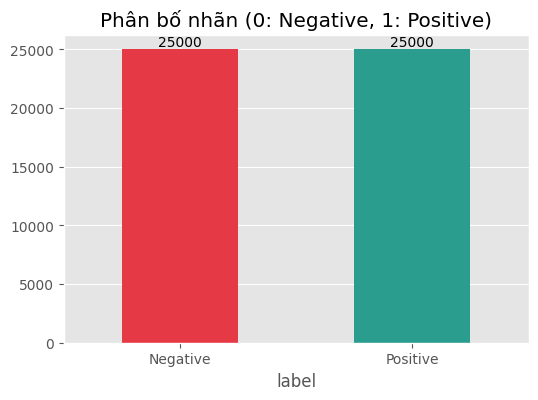

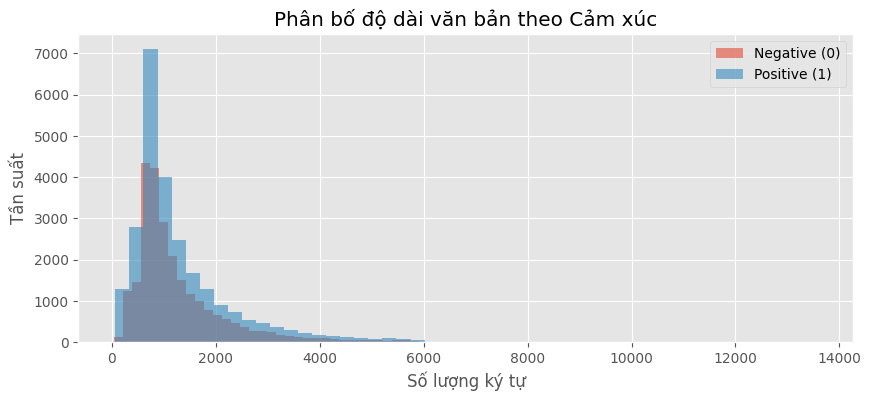

Đang tạo WordCloud...


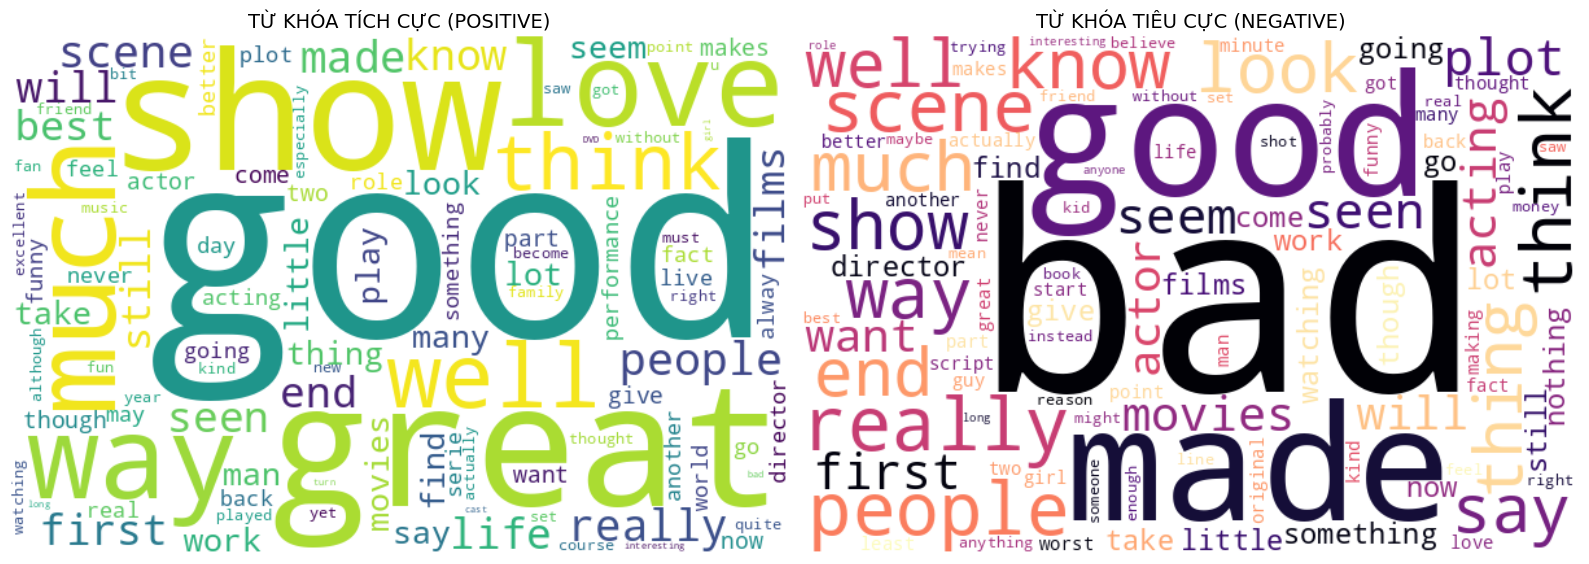

In [16]:
# 2.1. Kiểm tra cân bằng nhãn
plt.figure(figsize=(6,4))
ax = df["label"].value_counts().plot(kind="bar", color=["#e63946","#2a9d8f"])
plt.title("Phân bố nhãn (0: Negative, 1: Positive)")
plt.xticks(ticks=[0, 1], labels=["Negative", "Positive"], rotation=0)

# Thêm con số trên đầu cột
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')
plt.show()

# 2.2. Phân bố độ dài văn bản
plt.figure(figsize=(10,4))
df.groupby("label")["length"].hist(alpha=0.6, bins=50)
plt.title("Phân bố độ dài văn bản theo Cảm xúc")
plt.xlabel("Số lượng ký tự")
plt.ylabel("Tần suất")
plt.legend(["Negative (0)", "Positive (1)"])
plt.show()

# 2.3. WordCloud - Từ khóa phổ biến
print("Đang tạo WordCloud...")
my_stopwords = set(STOPWORDS)

# loại bỏ những từ thường xuất hiện ra khỏi worldcloud 
my_stopwords.update(["movie", "film", "one", "character", "characters", "make", "see", "time", "even", "story", "watch"])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive WordCloud
text_pos = " ".join(df[df["label"]==1]["review_clean"])
wc_pos = WordCloud(width=600, height=400, background_color="white", stopwords=my_stopwords, colormap="viridis", max_words=100).generate(text_pos)
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("TỪ KHÓA TÍCH CỰC (POSITIVE)", fontsize=14)

# Negative WordCloud
text_neg = " ".join(df[df["label"]==0]["review_clean"])
wc_neg = WordCloud(width=600, height=400, background_color="white", stopwords=my_stopwords,colormap="magma", max_words=100).generate(text_neg)
axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("TỪ KHÓA TIÊU CỰC (NEGATIVE)", fontsize=14)

plt.tight_layout()
plt.show()


## 3. Lưu dữ liệu đã làm sạch



In [10]:
output_path = "../backend/data/processed/IMDB_cleaned.csv"

# Chỉ lấy 2 cột: review sạch và label
df_export = df[["review_clean", "label"]].rename(columns={"review_clean": "review"})

df_export.to_csv(output_path, index=False)
print(f"Đã lưu file thành công tại: {output_path}")
print(f"Dung lượng dự kiến sẽ nhẹ hơn file gốc.")


Đã lưu file thành công tại: ../backend/data/processed/IMDB_cleaned.csv
Dung lượng dự kiến sẽ nhẹ hơn file gốc.
